<a href="https://colab.research.google.com/github/Cod4Nitish/Cod4Nitish/blob/main/Probabilistic_Modeling_and_AI_for_Healthcare_Monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Probabilistic Modeling and AI for Healthcare Monitoring

Name: Nitish Singh

Course: Machine Learning / Artificial Intelligence

Assignment Topic: Healthcare Data Analysis using Probabilistic Models

Short introduction:

**Modern healthcare systems collect large amounts of patient data through sensors and medical records. Machine learning and probabilistic models help doctors analyze this data and predict patient outcomes. In this assignment, we analyze a heart failure dataset using probability concepts, statistical estimation, and AI models. **

#Install and Import of  Libraries
pandas → dataset handle karne ke liye

numpy → mathematical calculations

matplotlib / seaborn → graphs banane ke liye

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#uploding dataset from kaggle


In [3]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

print("Dataset path:", path)

Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Dataset path: /kaggle/input/heart-failure-clinical-data


#loding dataset in pandas


In [4]:
data = pd.read_csv(path + "/heart_failure_clinical_records_dataset.csv")

data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


#checking dataset structure

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


#checking Statistical Summary

In [6]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


#Graph (Age vs Death)

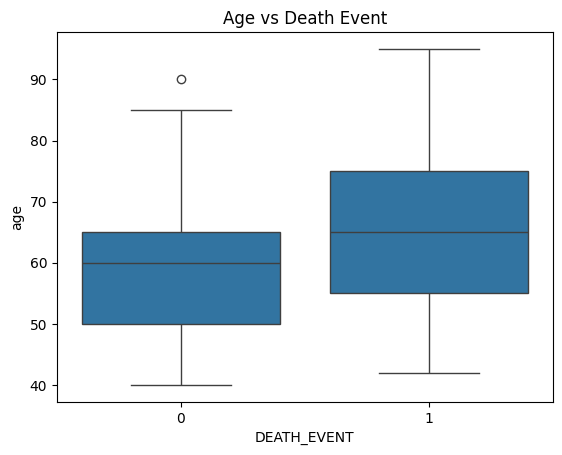

In [7]:
sns.boxplot(x="DEATH_EVENT", y="age", data=data)

plt.title("Age vs Death Event")

plt.show()

#Marginal probability = death event ka overall probability.

In [8]:
death_prob = data["DEATH_EVENT"].mean()

print("Marginal Probability of Death:", death_prob)

Marginal Probability of Death: 0.3210702341137124


#Joint Probability
Condition:

Age > 60

AND

Death event

In [9]:
joint_prob = ((data["age"] > 60) & (data["DEATH_EVENT"] == 1)).mean()

print("Joint Probability:", joint_prob)

Joint Probability: 0.17391304347826086


#conditional probability.

Death probability given age > 60

In [10]:
older = data[data["age"] > 60]

cond_prob = older["DEATH_EVENT"].mean()

print("Conditional Probability of Death given Age > 60:", cond_prob)

Conditional Probability of Death given Age > 60: 0.3795620437956204


#MLE dataset for best probability estimation

In [11]:
p_hat = data["DEATH_EVENT"].mean()

print("MLE Estimate of Death Probability:", p_hat)

MLE Estimate of Death Probability: 0.3210702341137124


#KL Divergence
for hospital assumption data and  real data kitna diffrence.

In [12]:
p = data["DEATH_EVENT"].mean()

q = 0.20

kl = p * np.log(p/q) + (1-p) * np.log((1-p)/(1-q))

print("KL Divergence:", kl)

KL Divergence: 0.04056786686634806


#Final Conclusion

This analysis shows how probability concepts and machine learning techniques can be applied to healthcare data. Marginal probability helps understand overall mortality risk. Conditional probability helps estimate risk for specific patient groups such as elderly patients. Maximum Likelihood Estimation provides the best probability estimate from observed data. KL divergence measures the difference between assumed and actual probability distributions. These techniques help healthcare systems improve patient monitoring and decision making.

#some graphs for better vizulization

#Graph 1 — Age Distribution

Ye graph batata hai dataset me patients ki age ka distribution.

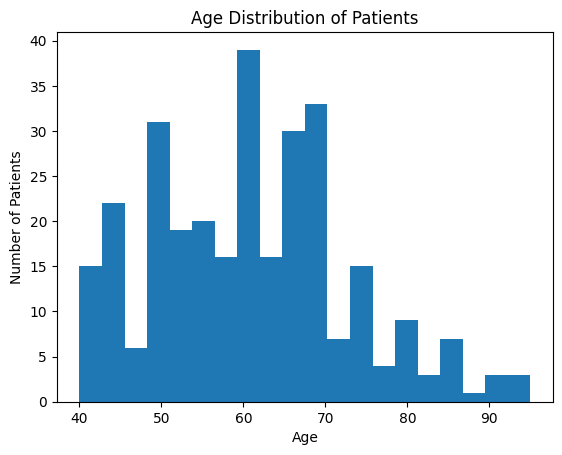

In [13]:
plt.hist(data["age"], bins=20)

plt.title("Age Distribution of Patients")

plt.xlabel("Age")

plt.ylabel("Number of Patients")

plt.show()

#Age distribution helps understand the demographic structure of the patient dataset.

#Graph 2 — Death Event Count

Ab dekhte hain kitne patients survive hue aur kitne died hue.

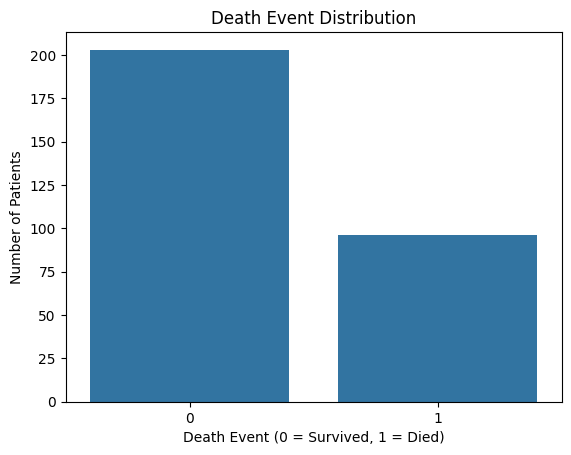

In [14]:
sns.countplot(x="DEATH_EVENT", data=data)

plt.title("Death Event Distribution")

plt.xlabel("Death Event (0 = Survived, 1 = Died)")

plt.ylabel("Number of Patients")

plt.show()

#This graph shows the distribution of survival and death events among patients.

#Graph 3 — Serum Creatinine vs Death

Ab medical factor analyze karte hain.

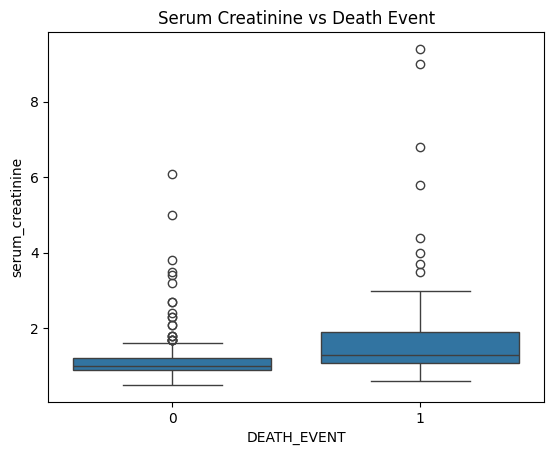

In [15]:
sns.boxplot(x="DEATH_EVENT", y="serum_creatinine", data=data)

plt.title("Serum Creatinine vs Death Event")

plt.show()

#Higher serum creatinine levels may indicate kidney dysfunction, which can increase mortality risk.

#Graph 4 — Age vs Serum Creatinine (Scatter Plot)

Ab relation dekhte hain.

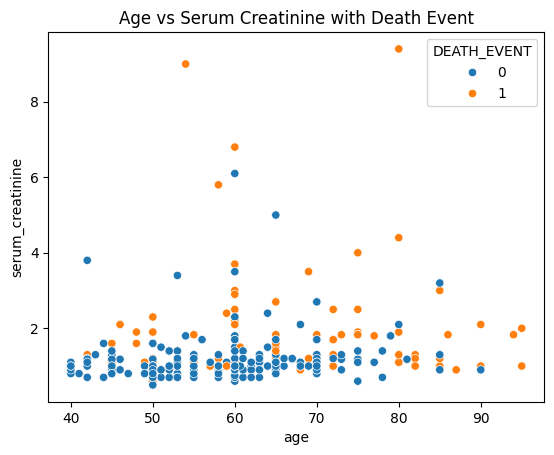

In [16]:
sns.scatterplot(x="age", y="serum_creatinine", hue="DEATH_EVENT", data=data)

plt.title("Age vs Serum Creatinine with Death Event")

plt.show()

#This visualization helps analyze the relationship between age, kidney function, and patient mortality.